# MAP5935 - Statistical Learning (Chapter 11 - Survival Analysis)

**Prof. Christian Jäkel**

https://www.statlearning.com/

In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

from ISLP import load_data
from ISLP.models import ModelSpec as MS

from sklearn.linear_model import \
    (LinearRegression ,
    LogisticRegression ,
    Lasso)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline

from sklearn.model_selection import \
    (train_test_split ,
    GridSearchCV)

from lifelines import KaplanMeierFitter

## *Conceptual Exercises*

### (8) Recall that the survival function $S(t)$, the hazard function $h(t)$, and the density function $f(t)$ are defined in equations $(1-3)$ below, respectively. Furthermore, define $F(t) = 1 − S(t)$.

###  Show that the following relationships hold:

$$ 
f(t)=dF(t)/dt
$$

$$ 
S(t)=\exp\Bigg(-\int_0^t h(u)du\Bigg)
$$

### Consider the following given relationships:
$$ 
S(t)=\Pr(T>t)\tag{1}
$$

$$
h(t)=\lim_{\Delta t\to 0}\frac{\Pr(t<T\leq t+\Delta t | T > t)}{\Delta t}\tag{2}
$$

$$
f(t)=\lim_{\Delta t\to 0}\frac{\Pr(t<T\leq t+\Delta t)}{\Delta t}\tag{3}
$$


**Solution** 

#### (1) Showing $ f(t) = \dfrac{dF(t)}{dt} $

For any $\Delta t>0$,

$$
F(t)=1-S(t)=1-\Pr(T>t)=P(T\leq t)
$$

Then we have

$$
F(t+\Delta t)-F(t)
= \Pr(T\le t+\Delta t) - \Pr(T\le t)
= \Pr(t< T \le t+\Delta t).
$$

Therefore, using the definition of $f(t)$ in equation $(3)$, we have:

$$
f(t)
= \lim_{\Delta t\to 0} \frac{\Pr(t< T\le t+\Delta t)}{\Delta t}
= \lim_{\Delta t\to 0} \frac{F(t+\Delta t)-F(t)}{\Delta t}
= \frac{dF(t)}{dt},
$$

i.e. $f$ is the derivative of the cdf $F$.

#### 2. Expressing $S(t)$ in terms of the hazard $h(t)$

First note that, using the definition of conditional probability,

$$
\Pr(t< T\le t+\Delta t \mid T>t)
= \frac{\Pr(t< T\le t+\Delta t ,\, T>t)}{\Pr(T>t)}
= \frac{\Pr(t< T\le t+\Delta t)}{S(t)}.
$$

Plugging this into the definition of the hazard,

$$
h(t)
= \lim_{\Delta t\to 0}
  \frac{ \Pr(t< T\le t+\Delta t \mid T>t)}{\Delta t}
= \lim_{\Delta t\to 0}
  \frac{ \Pr(t< T\le t+\Delta t)}{\Delta t\,S(t)}
= \frac{f(t)}{S(t)}.
$$

Thus

$$
f(t) = h(t)\,S(t).
$$

We also have $F(t)=1-S(t)$, so

$$
\frac{dS(t)}{dt}
= -\frac{dF(t)}{dt}
= -f(t)
= -h(t)\,S(t).
$$

Hence $S$ satisfies the differential equation

$$
\frac{dS(t)}{dt} = -h(t)\,S(t), \qquad S(0)=\Pr(T>0)=1.
$$

Solving it by separation of variables:

$$
\frac{dS(t)}{S(t)} = -h(t)\,dt
\quad\Longrightarrow\quad
\int_{S(0)}^{S(t)} \frac{1}{s}\,ds = -\int_0^t h(u)\,du,
$$

so

$$
\log S(t) - \log S(0) = -\int_0^t h(u)\,du.
$$

Since $S(0)=1$, $\log S(0)=0$, and we obtain

$$
\log S(t) = -\int_0^t h(u)\,du
\quad\Longrightarrow\quad
S(t) = \exp\!\left(-\int_0^t h(u)\,du\right).
$$

## *Applied Exercises*

### (10) This exercise focuses on the brain tumor data, which is included in the `ISLP` library.

### (a) Plot the Kaplan-Meier survival curve with ±1 standard error bands, using the `KaplanMeierFitter()` estimator in the `lifelines` package.

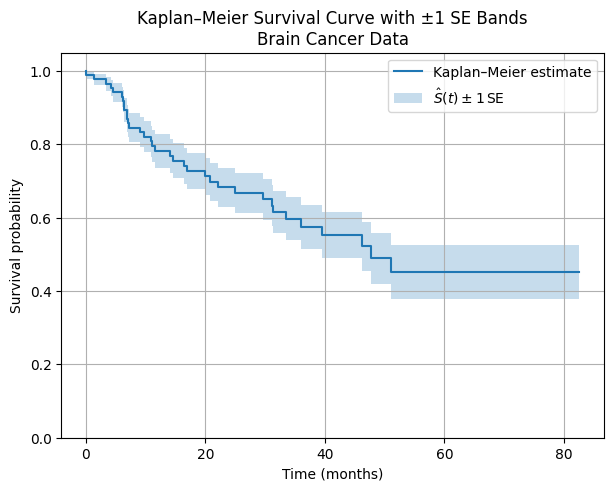

In [6]:
# Load data
BrainCancer = load_data("BrainCancer")

durations = BrainCancer["time"].values
events = BrainCancer["status"].values   # 1 = death, 0 = censored

# Fit Kaplan–Meier estimator
kmf = KaplanMeierFitter()
kmf.fit(durations=durations, event_observed=events, label="Kaplan–Meier")

# --- Greenwood standard errors ----------------------------------------------
# event_table has index = times, columns: 'at_risk', 'observed', 'censored', ...
ev_tab = kmf.event_table

n = ev_tab["at_risk"].values        # n_i
d = ev_tab["observed"].values       # d_i
S = kmf.survival_function_["Kaplan–Meier"].values  # \hat S(t_j)

# Greenwood sum: cumulative sum of d_i / [n_i (n_i - d_i)]
term = np.zeros_like(d, dtype=float)
mask = (n > 0) & (n - d > 0)        # avoid division by zero at the very end
term[mask] = d[mask] / (n[mask] * (n[mask] - d[mask]))

greenwood_sum = np.cumsum(term)
var_S = (S ** 2) * greenwood_sum
se_S = np.sqrt(var_S)

# Construct ± 1 SE bands, truncated to [0, 1]
lower = np.clip(S - se_S, 0, 1)
upper = np.clip(S + se_S, 0, 1)
t = kmf.survival_function_.index

# --- Plot KM curve with ±1 SE bands -----------------------------------------
plt.figure(figsize=(7, 5))
plt.step(t, S, where="post", label="Kaplan–Meier estimate")
plt.fill_between(t, lower, upper, step="post", alpha=0.25,
                 label=r"$\hat S(t) \pm 1\,\mathrm{SE}$")

plt.xlabel("Time (months)")
plt.ylabel("Survival probability")
plt.ylim(0, 1.05)
plt.title("Kaplan–Meier Survival Curve with ±1 SE Bands\nBrain Cancer Data")
plt.legend()
plt.grid(True)
plt.show()

### (b) Draw a bootstrap sample of size $n = 88$ from the pairs $(y_i, \delta_i)$, and compute the resulting Kaplan-Meier survival curve. Repeat this process $B = 200$ times. Use the results to obtain an estimate of the standard error of the Kaplan-Meier survival curve at each timepoint. Compare this to the standard errors obtained in (a).

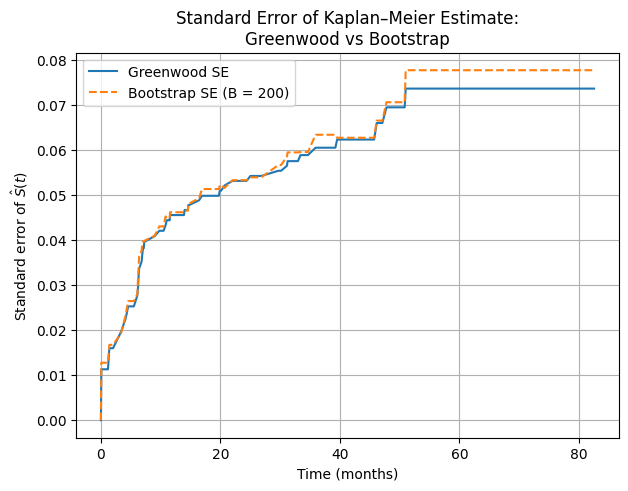

In [7]:
# -------------------------------------------------------------------
# Original KM fit and Greenwood standard errors (from part a)
# -------------------------------------------------------------------
durations = BrainCancer["time"].values
events = BrainCancer["status"].values   # 1 = death, 0 = censored
n = len(BrainCancer)                    # should be 88

kmf = KaplanMeierFitter()
kmf.fit(durations, events)

# Time grid and KM estimate
t_grid = kmf.survival_function_.index.values
S_hat = kmf.survival_function_.iloc[:, 0].values

# Greenwood SE
ev_tab = kmf.event_table
n_at_risk = ev_tab["at_risk"].values
d_obs = ev_tab["observed"].values

term = np.zeros_like(d_obs, dtype=float)
mask = (n_at_risk > 0) & (n_at_risk - d_obs > 0)
term[mask] = d_obs[mask] / (n_at_risk[mask] * (n_at_risk[mask] - d_obs[mask]))

greenwood_sum = np.cumsum(term)
var_greenwood = (S_hat ** 2) * greenwood_sum
se_greenwood = np.sqrt(var_greenwood)

# -------------------------------------------------------------------
# Bootstrap estimate of the standard error of S(t)
# -------------------------------------------------------------------
B = 200
boot_surv = np.empty((B, len(t_grid)))

rng = np.random.default_rng(seed=123)   # fix seed for reproducibility

for b in range(B):
    # sample n pairs (time, status) with replacement
    idx = rng.integers(low=0, high=n, size=n)
    durations_b = durations[idx]
    events_b = events[idx]

    kmf_b = KaplanMeierFitter()
    kmf_b.fit(durations_b, events_b)

    # Evaluate the bootstrap KM curve on the original time grid
    boot_surv[b, :] = kmf_b.predict(t_grid)

# Bootstrap SE at each time point:
#   \widehat{\mathrm{SE}}_\text{boot}(\hat S(t_j))
se_boot = boot_surv.std(axis=0, ddof=1)

# -------------------------------------------------------------------
# Compare Greenwood vs bootstrap SEs
# -------------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(t_grid, se_greenwood, label="Greenwood SE", linestyle="-")
plt.plot(t_grid, se_boot, label="Bootstrap SE (B = 200)", linestyle="--")

plt.xlabel("Time (months)")
plt.ylabel(r"Standard error of $\hat S(t)$")
plt.title("Standard Error of Kaplan–Meier Estimate:\nGreenwood vs Bootstrap")
plt.legend()
plt.grid(True)
plt.show()
